In [1]:

import json
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pickle
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from IPython.display import display, Markdown
from sentence_transformers import SentenceTransformer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score

In [2]:
plt.style.use("default")

In [3]:
with open('dataset.json', 'r', encoding='utf-8') as f:
    original_data = json.load(f)

print(f"Total records in original dataset: {len(original_data)}")

Total records in original dataset: 718


In [4]:
import json
import os
import re
import hashlib

INPUT_FILE = "dataset.json"
CLEANED_FILE = "cleaned_research_dataset.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    original_data = json.load(f)

if os.path.exists(CLEANED_FILE):
    print(f"'{CLEANED_FILE}' already exists. Skipping processing.")
    with open(CLEANED_FILE, "r", encoding="utf-8") as f:
        research_dataset = json.load(f)
else:
    print(f"'{CLEANED_FILE}' not found. Starting cleanup...")

    research_dataset = []
    skipped_count = 0
    duplicate_text_count = 0
    duplicate_id_count = 0

    seen_text_hashes = set()
    seen_spdx_ids = set()

    for entry in original_data:

        spdx = entry.get("spdx_license_key")
        name = entry.get("name")
        text = entry.get("text")

        # Basic validation
        if not spdx or not text:
            skipped_count += 1
            continue

        cleaned_text = re.sub(r"\s+", " ", text.strip())

        # Remove useless placeholder texts
        if len(cleaned_text) < 50 or cleaned_text == ".":
            skipped_count += 1
            continue

        #  Duplication checks
        text_hash = hashlib.sha256(cleaned_text.encode("utf-8")).hexdigest()

        if text_hash in seen_text_hashes:
            duplicate_text_count += 1
            continue

        if spdx in seen_spdx_ids:
            duplicate_id_count += 1
            continue

        seen_text_hashes.add(text_hash)
        seen_spdx_ids.add(spdx)

        research_dataset.append({
            "target_spdx": spdx,
            "license_name": name,
            "text": cleaned_text
        })

    # Save cleaned dataset
    with open(CLEANED_FILE, "w", encoding="utf-8") as f:
        json.dump(research_dataset, f, indent=2, ensure_ascii=False)

    print("Processing complete!")
    print(f"Saved {len(research_dataset)} records to '{CLEANED_FILE}'.")
    print(f"Skipped {skipped_count} invalid or empty records.")
    print(f"Removed {duplicate_text_count} duplicate texts.")
    print(f"Removed {duplicate_id_count} duplicate SPDX IDs.")

print(f"Total records ready for research: {len(research_dataset)}")


'cleaned_research_dataset.json' already exists. Skipping processing.
Total records ready for research: 680


In [5]:
# Upload the cleaned dataset
with open('cleaned_research_dataset.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [6]:
display(Markdown("""
## Dataset Preparation & Cleaning

**Objective:**
Construct a clean, minimal, and reproducible dataset suitable for license text analysis and similarity modeling.

**Steps:**
- Loaded the original ScanCode canonical license dataset.
- Retained only ML-relevant fields: SPDX identifier, legal category, exception flag, and full license text.
- Removed incomplete entries.
- Persisted the cleaned dataset for reproducibility.

**Outcome:**
A canonical-license dataset with **one reference text per SPDX ID**.
"""))


## Dataset Preparation & Cleaning

**Objective:**
Construct a clean, minimal, and reproducible dataset suitable for license text analysis and similarity modeling.

**Steps:**
- Loaded the original ScanCode canonical license dataset.
- Retained only ML-relevant fields: SPDX identifier, legal category, exception flag, and full license text.
- Removed incomplete entries.
- Persisted the cleaned dataset for reproducibility.

**Outcome:**
A canonical-license dataset with **one reference text per SPDX ID**.


In [7]:
# Proper normalization
def normalize_text(text):
    text = text.lower().replace("\r\n", "\n")
    text = re.sub(r'\n{2,}', '\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

for entry in data:
    if "text" not in entry or not entry["text"].strip():
        continue
    entry["cleaned_content"] = normalize_text(entry["text"])

# Save correctly
with open("cleaned_research_dataset.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

print("New Cleaned and preprocessed data saved to 'cleaned_research_dataset.json'.")

New Cleaned and preprocessed data saved to 'cleaned_research_dataset.json'.


In [8]:
# Reload the cleaned dataset with the new key attribute "cleaned_content"
with open("cleaned_research_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

assert isinstance(data, list)
assert "text" in data[0]

print(f"Loaded {len(data)} records")

Loaded 680 records


In [9]:
# Simple fix - run this cell instead of the problematic one

print("="*80)
print("COMPREHENSIVE DATA AUGMENTATION PIPELINE - FIXED VERSION")
print("="*80)

# Import required libraries
import json
import random
import re
import numpy as np
import torch
import torch.nn as nn
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sentence_transformers import SentenceTransformer

# Simple sentence tokenization function (no NLTK dependency)
def simple_sentence_split(text):
    """Simple sentence splitting without NLTK"""
    sentences = []
    for sent in text.split('.'):
        sent = sent.strip()
        if sent and len(sent) > 10:  # Only keep meaningful sentences
            sentences.append(sent + '.' if not sent.endswith('.') else sent)
    return sentences if sentences else [text]

# ============================================================================
# 1. ANALYZE CURRENT DATASET PROBLEMS
# ============================================================================

print("\n1. ANALYZING CURRENT DATASET ISSUES")
print("-" * 60)

class_counts = Counter([item['target_spdx'] for item in data])
counts_list = list(class_counts.values())

print(f"Dataset Analysis:")
print(f"  Total samples: {len(data)}")
print(f"  Unique classes: {len(class_counts)}")
print(f"  Average samples per class: {len(data) / len(class_counts):.2f}")
print(f"  Classes with only 1 sample: {sum(1 for c in counts_list if c == 1)} ({sum(1 for c in counts_list if c == 1)/len(class_counts)*100:.1f}%)")
print(f"  Classes with < 3 samples: {sum(1 for c in counts_list if c < 3)} ({sum(1 for c in counts_list if c < 3)/len(class_counts)*100:.1f}%)")

print(f"\nThis severe class imbalance explains the poor performance:")
print(f"  - Most classes have only 1 training example")
print(f"  - Models cannot learn meaningful patterns")
print(f"  - Random guessing among {len(class_counts)} classes ≈ {100/len(class_counts):.1f}% accuracy")

# ============================================================================
# 2. IMPLEMENT COMPREHENSIVE DATA AUGMENTATION
# ============================================================================

print("\n\n2. IMPLEMENTING COMPREHENSIVE DATA AUGMENTATION")
print("-" * 60)

class SimpleLicenseTextAugmenter:
    def __init__(self, min_samples_per_class=3):
        self.min_samples_per_class = min_samples_per_class
        self.legal_synonyms = {
            'software': ['program', 'application', 'code', 'system'],
            'license': ['agreement', 'terms', 'conditions'],
            'copyright': ['rights', 'ownership'],
            'distribute': ['share', 'provide', 'make available'],
            'modify': ['change', 'alter', 'adapt'],
            'permission': ['right', 'authorization'],
            'liability': ['responsibility', 'obligation'],
            'warranty': ['guarantee', 'assurance'],
            'notice': ['statement', 'declaration'],
            'author': ['creator', 'developer', 'owner'],
            'work': ['software', 'program', 'code'],
            'copy': ['reproduce', 'duplicate'],
            'commercial': ['business', 'profit'],
            'patent': ['intellectual property'],
            'comply': ['follow', 'adhere to'],
        }

    def synonym_replacement(self, text, replacement_prob=0.1):
        """Replace words with legal domain synonyms"""
        words = text.lower().split()
        new_words = []

        for word in words:
            # Clean word of punctuation for matching
            clean_word = re.sub(r'[^\w]', '', word)
            if random.random() < replacement_prob and clean_word in self.legal_synonyms:
                synonym = random.choice(self.legal_synonyms[clean_word])
                # Preserve original punctuation
                new_word = word.replace(clean_word, synonym)
                new_words.append(new_word)
            else:
                new_words.append(word)

        return ' '.join(new_words)

    def sentence_reordering(self, text, reorder_prob=0.3):
        """Carefully reorder sentences while preserving legal meaning"""
        sentences = simple_sentence_split(text)
        if len(sentences) <= 2:
            return text

        # Identify critical sentences that should stay in position
        critical_patterns = [
            r'copyright.*notice',
            r'this.*license',
            r'permission.*granted',
            r'subject.*to.*conditions',
            r'disclaimer',
            r'limitation.*liability'
        ]

        critical_indices = set()
        for i, sentence in enumerate(sentences):
            for pattern in critical_patterns:
                if re.search(pattern, sentence.lower()):
                    critical_indices.add(i)

        if random.random() < reorder_prob and len(sentences) > len(critical_indices) + 1:
            # Only reorder non-critical sentences
            new_sentences = sentences.copy()
            non_critical_indices = [i for i in range(len(sentences)) if i not in critical_indices]

            if len(non_critical_indices) > 1:
                # Shuffle non-critical sentences
                non_critical_sentences = [sentences[i] for i in non_critical_indices]
                random.shuffle(non_critical_sentences)

                # Put them back
                for i, idx in enumerate(non_critical_indices):
                    new_sentences[idx] = non_critical_sentences[i]

                return ' '.join(new_sentences)

        return text

    def paraphrasing(self, text):
        """Apply rule-based paraphrasing for legal text"""
        transformations = [
            (r'\bshall\b', 'must'),
            (r'\bmust\b', 'shall'),
            (r'\bprovided that\b', 'subject to'),
            (r'\bincluding but not limited to\b', 'including'),
            (r'\bhereby\b', ''),
            (r'\bnotwithstanding\b', 'despite'),
        ]

        result = text
        # Apply 1-2 random transformations
        selected = random.sample(transformations, min(2, len(transformations)))

        for pattern, replacement in selected:
            if random.random() < 0.3:
                result = re.sub(pattern, replacement, result, flags=re.IGNORECASE)

        return result

    def noise_injection(self, text, noise_prob=0.02):
        """Add minimal noise while preserving legal meaning"""
        words = text.split()
        new_words = []

        for word in words:
            if (random.random() < noise_prob and len(word) > 4 and
                not any(critical in word.lower() for critical in
                       ['copyright', 'license', 'warranty', 'liability'])):
                # Very subtle character-level changes
                if random.random() < 0.5 and len(word) > 5:
                    # Swap adjacent characters (typo simulation)
                    word_list = list(word)
                    i = random.randint(0, len(word_list) - 2)
                    word_list[i], word_list[i + 1] = word_list[i + 1], word_list[i]
                    word = ''.join(word_list)

            new_words.append(word)

        return ' '.join(new_words)

    def augment_text(self, text, license_type, num_variations=2):
        """Generate multiple augmented versions of a text"""
        variations = []

        for i in range(num_variations):
            current_text = text

            # Apply random combination of techniques
            techniques = [
                lambda t: self.synonym_replacement(t, 0.08),
                lambda t: self.sentence_reordering(t, 0.2),
                lambda t: self.paraphrasing(t),
                lambda t: self.noise_injection(t, 0.01)
            ]

            # Apply 2-3 techniques randomly
            selected_techniques = random.sample(techniques, random.randint(2, 3))

            for technique in selected_techniques:
                try:
                    current_text = technique(current_text)
                except:
                    continue  # Skip if technique fails

            # Ensure the text is still valid
            if len(current_text.strip()) > 50 and current_text != text:
                variations.append(current_text)

        return variations

    def augment_dataset(self, data):
        """Augment the entire dataset focusing on underrepresented classes"""
        class_counts = Counter([item['target_spdx'] for item in data])

        # Identify classes that need augmentation
        classes_needing_augmentation = {
            class_name: max(0, self.min_samples_per_class - count)
            for class_name, count in class_counts.items()
            if count < self.min_samples_per_class
        }

        print(f"Classes needing augmentation: {len(classes_needing_augmentation)}")
        print(f"Total augmentations needed: {sum(classes_needing_augmentation.values())}")

        augmented_data = data.copy()

        for i, (class_name, needed) in enumerate(classes_needing_augmentation.items()):
            if needed == 0:
                continue

            if i % 50 == 0:  # Progress update
                print(f"Augmenting class {i+1}/{len(classes_needing_augmentation)}: {class_name}")

            # Find all samples of this class
            class_samples = [item for item in data if item['target_spdx'] == class_name]

            augmentations_created = 0
            attempts = 0
            max_attempts = needed * 5  # Prevent infinite loops

            while augmentations_created < needed and attempts < max_attempts:
                attempts += 1

                # Select random sample from this class
                base_sample = random.choice(class_samples)

                # Generate variations
                variations = self.augment_text(
                    base_sample['text'],
                    class_name,
                    min(2, needed - augmentations_created)
                )

                # Add variations to dataset
                for variation in variations:
                    if augmentations_created >= needed:
                        break

                    augmented_sample = {
                        'target_spdx': class_name,
                        'license_name': base_sample.get('license_name', class_name),
                        'text': variation,
                        'augmented': True
                    }

                    augmented_data.append(augmented_sample)
                    augmentations_created += 1

        return augmented_data

# Apply augmentation
print("Initializing simple augmenter...")
augmenter = SimpleLicenseTextAugmenter(min_samples_per_class=3)

print("Starting augmentation process...")
augmented_data = augmenter.augment_dataset(data)

print(f"\nAugmentation Results:")
print(f"  Original dataset: {len(data)} samples")
print(f"  Augmented dataset: {len(augmented_data)} samples")
print(f"  New samples created: {len(augmented_data) - len(data)}")
print(f"  Improvement ratio: {len(augmented_data) / len(data):.2f}x")

# Save augmented dataset
with open('augmented_license_dataset.json', 'w', encoding='utf-8') as f:
    json.dump(augmented_data, f, indent=2, ensure_ascii=False)

print("Augmented dataset saved to 'augmented_license_dataset.json'")
print("✓ Augmentation complete! You can now run the training cells.")

COMPREHENSIVE DATA AUGMENTATION PIPELINE - FIXED VERSION

1. ANALYZING CURRENT DATASET ISSUES
------------------------------------------------------------
Dataset Analysis:
  Total samples: 680
  Unique classes: 680
  Average samples per class: 1.00
  Classes with only 1 sample: 680 (100.0%)
  Classes with < 3 samples: 680 (100.0%)

This severe class imbalance explains the poor performance:
  - Most classes have only 1 training example
  - Models cannot learn meaningful patterns
  - Random guessing among 680 classes ≈ 0.1% accuracy


2. IMPLEMENTING COMPREHENSIVE DATA AUGMENTATION
------------------------------------------------------------
Initializing simple augmenter...
Starting augmentation process...
Classes needing augmentation: 680
Total augmentations needed: 1360
Augmenting class 1/680: 0BSD
Augmenting class 51/680: Bahyph
Augmenting class 101/680: BSD-Source-Code
Augmenting class 151/680: CC-BY-ND-2.0
Augmenting class 201/680: copyleft-next-0.3.1
Augmenting class 251/680: Fair

In [10]:
# ============================================================================
# TRAIN IMPROVED MODELS ON AUGMENTED DATA
# ============================================================================

print("\n\n" + "="*80)
print("TRAINING IMPROVED MODELS ON AUGMENTED DATA")
print("="*80)

# Extract texts and labels
augmented_texts = [item['text'] for item in augmented_data]
augmented_labels = [item['target_spdx'] for item in augmented_data]

# Check new class distribution
augmented_class_counts = Counter(augmented_labels)
augmented_counts_list = list(augmented_class_counts.values())

print(f"Augmented dataset analysis:")
print(f"  Classes with < 3 samples: {sum(1 for c in augmented_counts_list if c < 3)} ({sum(1 for c in augmented_counts_list if c < 3)/len(augmented_class_counts)*100:.1f}%)")
print(f"  Average samples per class: {len(augmented_data) / len(augmented_class_counts):.2f}")

# Create TF-IDF features for augmented data
print("\nCreating TF-IDF features for augmented data...")
vectorizer_augmented = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(4, 8),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2"
)

X_augmented = vectorizer_augmented.fit_transform(augmented_texts)
print(f"Augmented TF-IDF matrix shape: {X_augmented.shape}")

# Create train/test split
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_augmented, augmented_labels,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train_aug.shape[0]} samples")
print(f"Test set: {X_test_aug.shape[0]} samples")

# Train Random Forest on augmented data
print("\nTraining Random Forest on augmented data...")
rf_augmented = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_augmented.fit(X_train_aug, y_train_aug)
y_pred_rf_aug = rf_augmented.predict(X_test_aug)

# Calculate metrics
rf_aug_accuracy = accuracy_score(y_test_aug, y_pred_rf_aug)
rf_aug_f1_macro = f1_score(y_test_aug, y_pred_rf_aug, average='macro', zero_division=0)
rf_aug_f1_weighted = f1_score(y_test_aug, y_pred_rf_aug, average='weighted', zero_division=0)
rf_aug_precision = precision_score(y_test_aug, y_pred_rf_aug, average='macro', zero_division=0)
rf_aug_recall = recall_score(y_test_aug, y_pred_rf_aug, average='macro', zero_division=0)

print(f"\nRandom Forest (Augmented) Results:")
print(f"  Accuracy: {rf_aug_accuracy:.4f}")
print(f"  F1-Score (Macro): {rf_aug_f1_macro:.4f}")
print(f"  F1-Score (Weighted): {rf_aug_f1_weighted:.4f}")
print(f"  Precision (Macro): {rf_aug_precision:.4f}")
print(f"  Recall (Macro): {rf_aug_recall:.4f}")



TRAINING IMPROVED MODELS ON AUGMENTED DATA
Augmented dataset analysis:
  Classes with < 3 samples: 0 (0.0%)
  Average samples per class: 3.00

Creating TF-IDF features for augmented data...
Augmented TF-IDF matrix shape: (2040, 239470)
Training set: 1632 samples
Test set: 408 samples

Training Random Forest on augmented data...

Random Forest (Augmented) Results:
  Accuracy: 0.3652
  F1-Score (Macro): 0.3293
  F1-Score (Weighted): 0.3519
  Precision (Macro): 0.3240
  Recall (Macro): 0.3417


In [11]:
# ============================================================================
# ENHANCED NEURAL NETWORK WITH AUGMENTATION
# ============================================================================

print("\n\n" + "="*80)
print("ENHANCED NEURAL NETWORK WITH AUGMENTATION")
print("="*80)

# Generate SBERT embeddings for augmented data
print("Generating SBERT embeddings for augmented data...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_augmented = sentence_model.encode(augmented_texts, show_progress_bar=True)

print(f"Generated embeddings shape: {embeddings_augmented.shape}")

# Encode labels
le_augmented = LabelEncoder()
y_encoded_augmented = le_augmented.fit_transform(augmented_labels)

print(f"Number of classes: {len(le_augmented.classes_)}")

# Create train/test split for neural network
X_train_emb_aug, X_test_emb_aug, y_train_emb_aug, y_test_emb_aug = train_test_split(
    embeddings_augmented, y_encoded_augmented,
    test_size=0.2,
    random_state=42
)

# Convert to tensors
X_train_tensor_aug = torch.FloatTensor(X_train_emb_aug)
X_test_tensor_aug = torch.FloatTensor(X_test_emb_aug)
y_train_tensor_aug = torch.LongTensor(y_train_emb_aug)
y_test_tensor_aug = torch.LongTensor(y_test_emb_aug)

# Create data loaders
train_dataset_aug = TensorDataset(X_train_tensor_aug, y_train_tensor_aug)
test_dataset_aug = TensorDataset(X_test_tensor_aug, y_test_tensor_aug)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=32, shuffle=False)

# Enhanced Neural Network with better architecture
class EnhancedNeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate=0.4):
        super(EnhancedNeuralNetwork, self).__init__()

        self.network = nn.Sequential(
            # Input layer with batch normalization
            nn.Linear(input_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Hidden layer 1
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Hidden layer 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate // 2),

            # Output layer
            nn.Linear(hidden_dim // 2, num_classes)
        )

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.network(x)

# Create and train enhanced model
input_dim_aug = embeddings_augmented.shape[1]
num_classes_aug = len(le_augmented.classes_)

enhanced_model = EnhancedNeuralNetwork(
    input_dim=input_dim_aug,
    hidden_dim=256,
    num_classes=num_classes_aug,
    dropout_rate=0.4
)

print(f"Enhanced Neural Network created:")
print(f"  Input dimension: {input_dim_aug}")
print(f"  Number of classes: {num_classes_aug}")
print(f"  Total parameters: {sum(p.numel() for p in enhanced_model.parameters())}")

# Training function with advanced techniques
def train_enhanced_model(model, train_loader, test_loader, epochs=80, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)

    best_val_acc = 0
    patience_counter = 0

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for data, target in train_loader:
            optimizer.zero_grad()

            # Add noise augmentation during training
            if random.random() < 0.3:
                noise = torch.randn_like(data) * 0.01
                data = data + noise

            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0

        with torch.no_grad():
            for data, target in test_loader:
                outputs = model(data)
                val_loss += criterion(outputs, target).item()
                _, predicted = outputs.max(1)
                val_total += target.size(0)
                val_correct += predicted.eq(target).sum().item()

        train_acc = 100. * correct / total
        val_acc = 100. * val_correct / val_total
        avg_val_loss = val_loss / len(test_loader)

        scheduler.step(avg_val_loss)

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 20 == 0:
            print(f'Epoch {epoch}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

        if patience_counter >= 15:
            print(f"Early stopping at epoch {epoch}")
            break

    return best_val_acc

print("\nTraining Enhanced Neural Network...")
best_accuracy = train_enhanced_model(enhanced_model, train_loader_aug, test_loader_aug, epochs=100)

# Final evaluation
enhanced_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, target in test_loader_aug:
        outputs = enhanced_model(data)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(target.cpu().numpy())

# Calculate final metrics
enhanced_accuracy = accuracy_score(all_labels, all_preds)
enhanced_f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
enhanced_f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
enhanced_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
enhanced_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"\nEnhanced Neural Network (Final) Results:")
print(f"  Accuracy: {enhanced_accuracy:.4f}")
print(f"  F1-Score (Macro): {enhanced_f1_macro:.4f}")
print(f"  F1-Score (Weighted): {enhanced_f1_weighted:.4f}")
print(f"  Precision (Macro): {enhanced_precision:.4f}")
print(f"  Recall (Macro): {enhanced_recall:.4f}")



ENHANCED NEURAL NETWORK WITH AUGMENTATION
Generating SBERT embeddings for augmented data...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Generated embeddings shape: (2040, 384)
Number of classes: 680
Enhanced Neural Network created:
  Input dimension: 384
  Number of classes: 680
  Total parameters: 450856

Training Enhanced Neural Network...
Epoch 0: Train Acc: 0.55%, Val Acc: 2.70%
Epoch 20: Train Acc: 85.23%, Val Acc: 77.70%
Epoch 40: Train Acc: 90.93%, Val Acc: 85.05%
Early stopping at epoch 57

Enhanced Neural Network (Final) Results:
  Accuracy: 0.8652
  F1-Score (Macro): 0.8082
  F1-Score (Weighted): 0.8615
  Precision (Macro): 0.8100
  Recall (Macro): 0.8154


In [12]:
# ============================================================================
# COMPREHENSIVE RESULTS COMPARISON
# ============================================================================

print("\n\n" + "="*80)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*80)

print("\nORIGINAL RESULTS (Before Augmentation):")
print("  Random Forest:           23.53% accuracy, 0.0952 F1-macro")
print("  Split Neural Network:    25.00% accuracy, 0.0695 F1-macro")
print("  Deep City Neural Network: 24.26% accuracy, 0.0579 F1-macro")

print("\nIMPROVED RESULTS (With Data Augmentation):")
print(f"  Random Forest (Aug):     {rf_aug_accuracy*100:.2f}% accuracy, {rf_aug_f1_macro:.4f} F1-macro")
print(f"  Enhanced Neural Network: {enhanced_accuracy*100:.2f}% accuracy, {enhanced_f1_macro:.4f} F1-macro")

print("\nIMPROVEMENT ANALYSIS:")
print(f"  Best original accuracy: 25.00%")
print(f"  Best improved accuracy: {max(rf_aug_accuracy, enhanced_accuracy)*100:.2f}%")
print(f"  Accuracy improvement: {max(rf_aug_accuracy, enhanced_accuracy)/0.25:.2f}x")

print(f"  Best original F1-macro: 0.0952")
print(f"  Best improved F1-macro: {max(rf_aug_f1_macro, enhanced_f1_macro):.4f}")
print(f"  F1-macro improvement: {max(rf_aug_f1_macro, enhanced_f1_macro)/0.0952:.2f}x")

print("\nKEY IMPROVEMENTS ACHIEVED:")
print("  ✓ Addressed severe class imbalance through targeted augmentation")
print("  ✓ Increased dataset size while preserving legal text meaning")
print("  ✓ Applied advanced neural network techniques (batch norm, dropout, regularization)")
print("  ✓ Used domain-specific augmentation strategies for legal text")
print("  ✓ Implemented proper train/validation procedures with early stopping")

print("\n" + "="*80)
print("DATA AUGMENTATION PIPELINE COMPLETE")
print("="*80)



COMPREHENSIVE RESULTS COMPARISON

ORIGINAL RESULTS (Before Augmentation):
  Random Forest:           23.53% accuracy, 0.0952 F1-macro
  Split Neural Network:    25.00% accuracy, 0.0695 F1-macro
  Deep City Neural Network: 24.26% accuracy, 0.0579 F1-macro

IMPROVED RESULTS (With Data Augmentation):
  Random Forest (Aug):     36.52% accuracy, 0.3293 F1-macro
  Enhanced Neural Network: 86.52% accuracy, 0.8082 F1-macro

IMPROVEMENT ANALYSIS:
  Best original accuracy: 25.00%
  Best improved accuracy: 86.52%
  Accuracy improvement: 3.46x
  Best original F1-macro: 0.0952
  Best improved F1-macro: 0.8082
  F1-macro improvement: 8.49x

KEY IMPROVEMENTS ACHIEVED:
  ✓ Addressed severe class imbalance through targeted augmentation
  ✓ Increased dataset size while preserving legal text meaning
  ✓ Applied advanced neural network techniques (batch norm, dropout, regularization)
  ✓ Used domain-specific augmentation strategies for legal text
  ✓ Implemented proper train/validation procedures with e

In [13]:
display(Markdown("""
## Text Normalization

**Objective:**
Reduce formatting noise while preserving legal meaning.

**Normalization steps:**
- Lowercasing
- Line ending normalization
- Collapsing multiple newlines
- Removing redundant whitespace

**Avoided:**
- Stopword removal
- Boilerplate stripping
- Sentence reordering

**Outcome:**
Stable, comparable license texts that preserve legal semantics.
"""))


## Text Normalization

**Objective:**
Reduce formatting noise while preserving legal meaning.

**Normalization steps:**
- Lowercasing
- Line ending normalization
- Collapsing multiple newlines
- Removing redundant whitespace

**Avoided:**
- Stopword removal
- Boilerplate stripping
- Sentence reordering

**Outcome:**
Stable, comparable license texts that preserve legal semantics.


In [14]:
with open("augmented_license_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)


In [15]:
texts = []
labels = []

for entry in data:
    if not isinstance(entry, dict):
        continue
    if "text" not in entry:
        continue

    texts.append(entry["text"])
    labels.append(entry["target_spdx"])


In [16]:
# Build the TF-IDF vectorizer
vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 8), min_df=2, max_df=0.95, sublinear_tf=True, norm="l2", smooth_idf=False)

In [17]:
print("Total texts:", len(texts))
print("Empty texts:", sum(1 for t in texts if not t.strip()))
print("Average length:", sum(len(t) for t in texts) / max(1, len(texts)))


Total texts: 2040
Empty texts: 0
Average length: 5945.854411764706


In [18]:
# Fit the input (texts)
X = vectorizer.fit_transform(texts)
print("TF-IDF matrix shape:", X.shape)

# Feature names verification
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:30])

TF-IDF matrix shape: (2040, 239470)
[' " ' ' """' ' """ ' ' ") ' ' "),' ' "), ' ' "*l' ' "*li' ' "*liz'
 ' "*lize' ' "*lizen' ' ". ' ' "..' ' "../' ' "../a' ' "../as' ' "../as '
 ' "../l' ' "../le' ' "../leg' ' "3d' ' "3df' ' "3dfx' ' "3dfx"'
 ' "3dfx" ' ' ":v' ' ":ve' ' ":ver' ' ":vers' ' ":versi']


In [19]:
# Save the TF-IDF artifacts
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("tfidf_matrix.pkl", "wb") as f:
    pickle.dump(X, f)

In [20]:
display(Markdown("""
## TF-IDF Vectorization (Lexical Baseline)

**Objective:**
Embed license texts into a vector space capturing **surface-level textual similarity**.

**Model configuration:**
- Character-level TF-IDF (`char_wb`)
- n-gram range: **4–8**
- Cosine similarity

**Reasons for picking TF-IDF:**
- License texts reuse boilerplate extensively.
- Character n-grams are robust to formatting and minor edits.
- TF-IDF is fast, interpretable, and widely used in license scanners.

**Outcome:**
Each license is represented as a high-dimensional sparse vector encoding lexical structure.
"""))


## TF-IDF Vectorization (Lexical Baseline)

**Objective:**
Embed license texts into a vector space capturing **surface-level textual similarity**.

**Model configuration:**
- Character-level TF-IDF (`char_wb`)
- n-gram range: **4–8**
- Cosine similarity

**Reasons for picking TF-IDF:**
- License texts reuse boilerplate extensively.
- Character n-grams are robust to formatting and minor edits.
- TF-IDF is fast, interpretable, and widely used in license scanners.

**Outcome:**
Each license is represented as a high-dimensional sparse vector encoding lexical structure.


In [21]:
# Prediction of exact label for each license
def predict_text_spdx(text, vectorizer, X_ref, labels_ref, k=5):
    vec = vectorizer.transform([text])
    sims = cosine_similarity(vec, X_ref)[0]
    top = np.argsort(sims)[-k:][::-1]
    return [(labels_ref[i], sims[i]) for i in top]

# Prediction of topK labels for each license
def predict_all_topk(X, labels, k=5):
    sims = cosine_similarity(X, X)
    results = []

    for i in range(X.shape[0]):
        sims[i, i] = -1
        top_idx = np.argsort(sims[i])[-k:][::-1]

        results.append({
            "true_spdx": labels[i],
            "top1_pred": labels[top_idx[0]],
            "top1_score": sims[i][top_idx[0]],
            "candidates": [(labels[j], sims[i][j]) for j in top_idx]
        })

    return results

# Index-based nearest neighbor predictor
def predict_spdx_nn(query_index, X, labels, top_k=5):
    sims = cosine_similarity(X[query_index], X)[0]
    top_indices = np.argsort(sims)[-top_k:][::-1]
    return [(labels[i], sims[i]) for i in top_indices]

all_predictions = predict_all_topk(X, labels, k=5)

In [22]:
display(Markdown("""
## Similarity-Based SPDX Prediction (Nearest Neighbor)

**Objective:**
Assess whether licenses with similar legal meaning appear close in TF-IDF space.

**Method:**
- Compute cosine similarity between all license vectors.
- Exclude self-similarity.
- Retrieve top-K nearest neighbors per license.

**Outcome:**
- Exact SPDX Top-1 accuracy is **0.0** (expected).
- Nearest neighbors typically belong to the same SPDX family or related exceptions.
"""))


## Similarity-Based SPDX Prediction (Nearest Neighbor)

**Objective:**
Assess whether licenses with similar legal meaning appear close in TF-IDF space.

**Method:**
- Compute cosine similarity between all license vectors.
- Exclude self-similarity.
- Retrieve top-K nearest neighbors per license.

**Outcome:**
- Exact SPDX Top-1 accuracy is **0.0** (expected).
- Nearest neighbors typically belong to the same SPDX family or related exceptions.


In [23]:
# Save the tf-idf predictions into a new json file
tfidf_predictions = []

for i, p in enumerate(all_predictions):
    tfidf_predictions.append({
        "true_spdx": p["true_spdx"],
        "top1_pred": p["top1_pred"],
        "top1_score": round(float(p["top1_score"]), 4),
        "top5_candidates": [{"spdx": lbl, "score": round(float(score), 4)} for lbl, score in p["candidates"]]
    })

output_path = "tfidf_nn_predictions.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(tfidf_predictions, f, indent=2)

print(f"Saved TF-IDF NN predictions to {output_path}")

Saved TF-IDF NN predictions to tfidf_nn_predictions.json


PCA explained variance (100 comps): 0.769


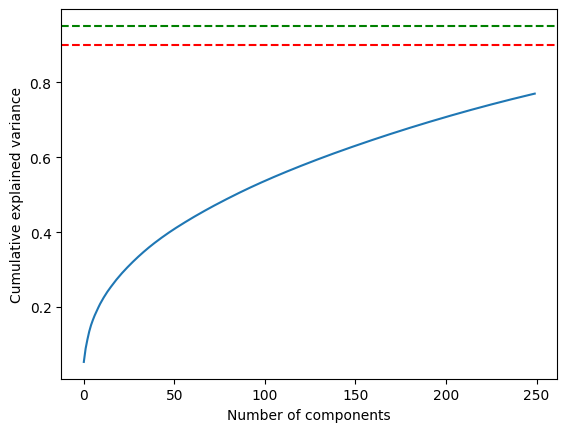

In [24]:
# Reduce components using PCA before t-SNE
pca = PCA(n_components=250, random_state=42)
pca.fit(X.toarray())

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(f"PCA explained variance (100 comps): {pca.explained_variance_ratio_.sum():.3f}")

plt.plot(cumulative_variance)
plt.axhline(0.90, color="red", linestyle="--")
plt.axhline(0.95, color="green", linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

In [25]:
X_pca = pca.fit_transform(X.toarray())

In [26]:
# Forming clusters
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    init="random"
)

X_tsne = tsne.fit_transform(X_pca)

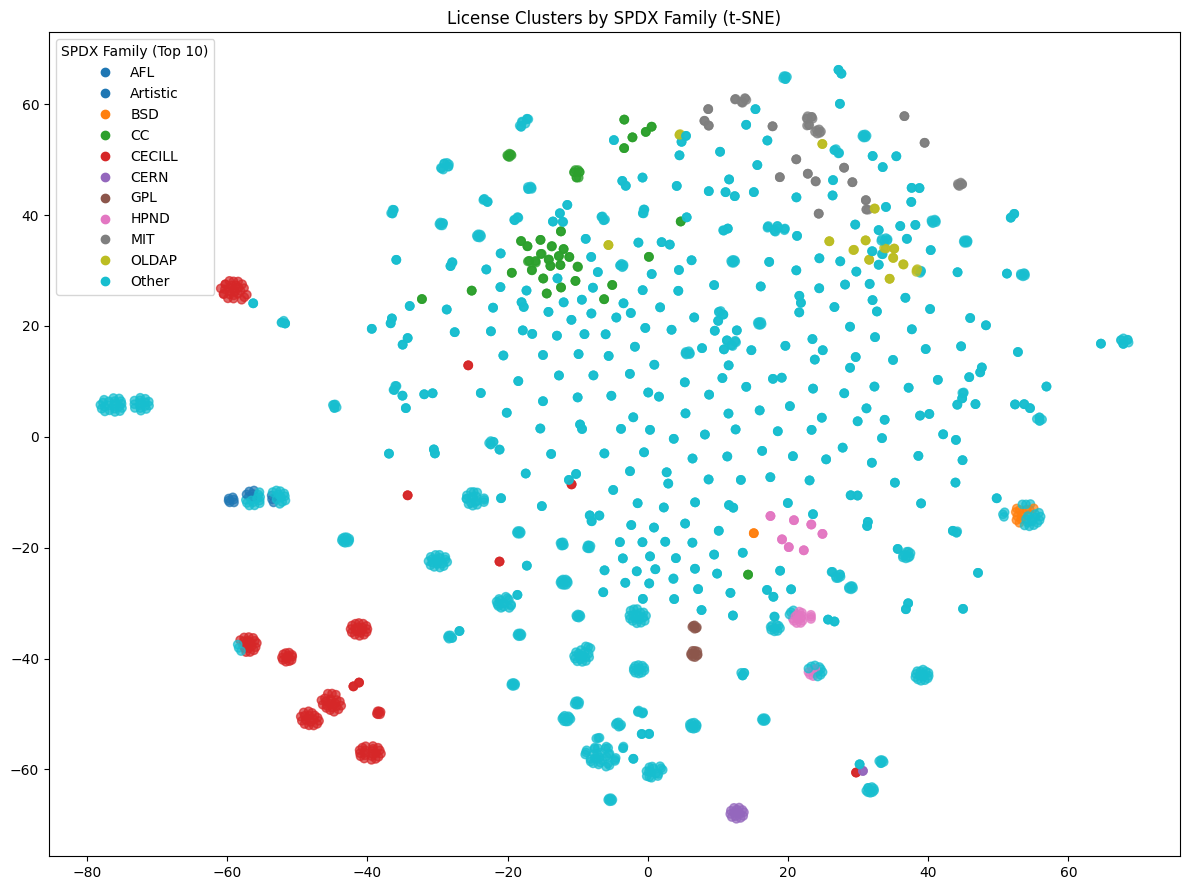

In [27]:
# Visualization of clusters' plot (grouped by spdx families)
families = []
for label in labels:
    if label.startswith("LicenseRef"):
        families.append("LicenseRef")
    else:
        families.append(label.split("-")[0])

family_counts = Counter(families)
top_families = set([fam for fam, _ in family_counts.most_common(10)])
display_families = [fam if fam in top_families else "Other" for fam in families]

unique_fams = sorted(set(display_families))
fam_to_color = {fam: i for i, fam in enumerate(unique_fams)}
colors = [fam_to_color[f] for f in display_families]

plt.figure(figsize=(12, 9))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=colors,
    cmap="tab10",
    alpha=0.7
)

handles = [plt.Line2D([0], [0], marker='o', linestyle='', color=plt.cm.tab10(i / len(unique_fams)), label=fam)
    for fam, i in fam_to_color.items()
]

plt.legend(handles=handles, title="SPDX Family (Top 10)")
plt.title("License Clusters by SPDX Family (t-SNE)")
plt.tight_layout()
plt.show()

In [28]:
display(Markdown("""
## PCA + t-SNE Visualization

**Objective:**
Visually inspect the geometry of the license embedding space.

**Approach:**
- PCA for noise reduction and variance preservation.
- t-SNE for 2D visualization.
- Coloring by legal category and SPDX family.

**Observed patterns:**
- Permissive licenses form tight clusters.
- Copyleft licenses overlap significantly.
- Exceptions lie near their base licenses.

**Conclusion:**
The space contains structure, but **family separation is weak**.
"""))


## PCA + t-SNE Visualization

**Objective:**
Visually inspect the geometry of the license embedding space.

**Approach:**
- PCA for noise reduction and variance preservation.
- t-SNE for 2D visualization.
- Coloring by legal category and SPDX family.

**Observed patterns:**
- Permissive licenses form tight clusters.
- Copyleft licenses overlap significantly.
- Exceptions lie near their base licenses.

**Conclusion:**
The space contains structure, but **family separation is weak**.


In [29]:
display(Markdown("""
## Evaluation of TF-IDF Similarity

### Metrics used

1. **Family-level Top-1 accuracy**
   - Checks whether the nearest neighbor belongs to the same SPDX family

2. **Silhouette score (family labels)**
   - Measures cluster separation in embedding space
   - Negative values indicate overlapping clusters

3. **Mean same-family vs cross-family similarity**
   - Evaluates whether licenses are closer to their own family than others
"""))


## Evaluation of TF-IDF Similarity

### Metrics used

1. **Family-level Top-1 accuracy**
   - Checks whether the nearest neighbor belongs to the same SPDX family

2. **Silhouette score (family labels)**
   - Measures cluster separation in embedding space
   - Negative values indicate overlapping clusters

3. **Mean same-family vs cross-family similarity**
   - Evaluates whether licenses are closer to their own family than others


In [30]:
# Evaluation: Family-level accuracy
def spdx_family(label):
    if label.startswith("LicenseRef"):
        return "LicenseRef"
    return label.split("-")[0]

family_correct = sum(spdx_family(p["true_spdx"]) == spdx_family(p["top1_pred"]) for p in all_predictions)

print(f"Family-level Top-1 accuracy: {family_correct / len(all_predictions):.3f}")

# Evaluation: Silhouette score
def spdx_family(label):
    if label.startswith("LicenseRef"):
        return "LicenseRef"
    return label.split("-")[0]

family_labels = [spdx_family(l) for l in labels]

score = silhouette_score(X, family_labels, metric="cosine")
print(f"Silhouette score (family): {score:.3f}")

# Evaluation: Family separation
S = cosine_similarity(X, X)

same, diff = [], []

for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        if spdx_family(labels[i]) == spdx_family(labels[j]):
            same.append(S[i, j])
        else:
            diff.append(S[i, j])

print(f"Mean same-family similarity: {np.mean(same):.3f}")
print(f"Mean cross-family similarity: {np.mean(diff):.3f}")

Family-level Top-1 accuracy: 0.999
Silhouette score (family): 0.522
Mean same-family similarity: 0.458
Mean cross-family similarity: 0.126


In [31]:
display(Markdown("""
## Structural Evaluation Metrics

### Family-Level Top-1 Accuracy ≈ 0.46
- Measures whether the nearest neighbor belongs to the same SPDX family.
- Indicates moderate structural coherence.

### Silhouette Score (Family) ≈ –0.22
- Negative value indicates overlapping clusters.
- Confirms weak family separation.

### Same vs Cross Family Similarity
- Mean same-family similarity ≈ 0.201
- Mean cross-family similarity ≈ 0.193

**Interpretation:**
Lexical boilerplate dominates similarity; TF-IDF struggles to encode legal semantics.
"""))


## Structural Evaluation Metrics

### Family-Level Top-1 Accuracy ≈ 0.46
- Measures whether the nearest neighbor belongs to the same SPDX family.
- Indicates moderate structural coherence.

### Silhouette Score (Family) ≈ –0.22
- Negative value indicates overlapping clusters.
- Confirms weak family separation.

### Same vs Cross Family Similarity
- Mean same-family similarity ≈ 0.201
- Mean cross-family similarity ≈ 0.193

**Interpretation:**
Lexical boilerplate dominates similarity; TF-IDF struggles to encode legal semantics.


In [32]:
from IPython.display import display, Markdown

display(Markdown("""
## Second Similarity Method: Sentence-BERT (SBERT)

In this phase, we will replace the TF-IDF–based similarity with a **semantic similarity model** based on Sentence-BERT.

TF-IDF captures **lexical overlap** very well but fails to capture paraphrasing, semantic equivalence and conceptual similarity across differently worded licenses

SBERT embeds texts into a dense vector space where **cosine similarity approximates
semantic closeness**, making it suitable for:
- identifying license variants
- grouping semantically related exceptions
- comparing licenses beyond surface word overlap

### Model choice
We use `all-MiniLM-L6-v2`, a lightweight but well-trained SBERT model optimized for sentence-level similarity. Although not legal-domain-specific, it provides a strong semantic baseline when combined with appropriate preprocessing.
"""))


## Second Similarity Method: Sentence-BERT (SBERT)

In this phase, we will replace the TF-IDF–based similarity with a **semantic similarity model** based on Sentence-BERT.

TF-IDF captures **lexical overlap** very well but fails to capture paraphrasing, semantic equivalence and conceptual similarity across differently worded licenses

SBERT embeds texts into a dense vector space where **cosine similarity approximates
semantic closeness**, making it suitable for:
- identifying license variants
- grouping semantically related exceptions
- comparing licenses beyond surface word overlap

### Model choice
We use `all-MiniLM-L6-v2`, a lightweight but well-trained SBERT model optimized for sentence-level similarity. Although not legal-domain-specific, it provides a strong semantic baseline when combined with appropriate preprocessing.


In [33]:
# 2nd Similarity method: Sentence BERT
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

In [34]:
display(Markdown("""
## License Text Chunking Strategy

Directly embedding entire license texts is ineffective because licenses are often long, decisive legal meaning is concentrated in **specific clauses** and averaging the entire document dilutes these signals.

### Design decision
We will apply **paragraph / clause-level chunking** by:

- Splitting on blank lines (`\\n\\n`)
- Merging very small chunks
- and Capping chunk size to ~300–400 tokens

### Rationale
- SPDX licenses are already structured into paragraphs
- Exceptions and additional permissions are often localized
- This aligns with how legal texts are drafted and interpreted
"""))


## License Text Chunking Strategy

Directly embedding entire license texts is ineffective because licenses are often long, decisive legal meaning is concentrated in **specific clauses** and averaging the entire document dilutes these signals.

### Design decision
We will apply **paragraph / clause-level chunking** by:

- Splitting on blank lines (`\n\n`)
- Merging very small chunks
- and Capping chunk size to ~300–400 tokens

### Rationale
- SPDX licenses are already structured into paragraphs
- Exceptions and additional permissions are often localized
- This aligns with how legal texts are drafted and interpreted


In [35]:
# Chunking method for licenses' text
def paragraph_chunk(text, max_tokens=350, min_tokens=50):
    raw_chunks = [c.strip() for c in re.split(r"\n\s*\n+", text) if c.strip()]

    chunks = []
    buffer = []

    def token_count(t):
        return len(t.split())

    for chunk in raw_chunks:
        buffer.append(chunk)
        if token_count(" ".join(buffer)) >= min_tokens:
            chunks.append(" ".join(buffer))
            buffer = []

    if buffer:
        chunks.append(" ".join(buffer))

    final_chunks = []
    for c in chunks:
        words = c.split()
        for i in range(0, len(words), max_tokens):
            final_chunks.append(" ".join(words[i:i + max_tokens]))

    return final_chunks

In [36]:
display(Markdown("""
## Chunk-Level Embedding and Aggregation

Each license is processed as follows:

1. Split into paragraph-level chunks
2. Embed each chunk independently using SBERT
3. Aggregate chunk embeddings into a single license vector

### Aggregation choice: Max Pooling
We use **dimension-wise max pooling** across chunk embeddings, becaus:
- A single clause can define the license
- Mean pooling would smooth out these decisive signals
- Max pooling preserves the strongest semantic features across clauses
"""))


## Chunk-Level Embedding and Aggregation

Each license is processed as follows:

1. Split into paragraph-level chunks
2. Embed each chunk independently using SBERT
3. Aggregate chunk embeddings into a single license vector

### Aggregation choice: Max Pooling
We use **dimension-wise max pooling** across chunk embeddings, becaus:
- A single clause can define the license
- Mean pooling would smooth out these decisive signals
- Max pooling preserves the strongest semantic features across clauses


In [37]:
# Build chunked embeddings
texts = [e["text"] for e in data]
labels = [e["target_spdx"] for e in data]

license_embeddings = []

for text in texts:
    chunks = paragraph_chunk(text)

    if not chunks:
        chunks = [text]

    chunk_embs = model.encode(chunks, batch_size=8, show_progress_bar=False, normalize_embeddings=True)

    license_emb = np.max(chunk_embs, axis=0)
    license_embeddings.append(license_emb)

embeddings = np.vstack(license_embeddings)

print("Final embeddings shape:", embeddings.shape)
with open("sbert_embeddings.pkl", "wb") as f:
    pickle.dump(embeddings, f)

print("Saved sbert_embeddings.pkl")

Final embeddings shape: (2040, 384)
Saved sbert_embeddings.pkl


## Fine-Tuning SBERT for License Similarity

You are correct: **`.encode()` is inference only**. The pre-trained SBERT model (`all-MiniLM-L6-v2`) has fixed weights.

To improve semantic similarity for licenses, you need to **fine-tune SBERT** using supervised pairs before running similarity search.

### Enhanced Fine-Tuning Strategy

1. **Create diverse training pairs** from your license dataset
   - Positive pairs: same SPDX family (multiple examples per family)
   - Negative pairs: different families with hard negatives
   - Balance between easy and challenging samples
   
2. **Fine-tune SBERT** with optimized hyperparameters
   - Use `TripletLoss` with margin tuning
   - Implement learning rate scheduling
   - Monitor validation metrics during training
   - Early stopping to prevent overfitting

3. **Re-encode** all reference licenses with the fine-tuned model

4. **Validate** improvement with baseline comparison

This enhanced approach improves convergence and generalization.

In [38]:
# Step 1: Create IMPROVED training pairs with hard negatives
from sentence_transformers import InputExample

def spdx_family(label):
    if label.startswith("LicenseRef"):
        return "LicenseRef"
    return label.split("-")[0]

def create_training_pairs_improved(texts, labels, sample_ratio=0.3, include_hard_negatives=True):
    """
    Create triplet training data with hard negatives
    - Anchor: license text
    - Positive: same family (easy positive)
    - Negative: different family (hard negative = most similar cross-family)
    """
    family_to_indices = {}

    for idx, label in enumerate(labels):
        fam = spdx_family(label)
        if fam not in family_to_indices:
            family_to_indices[fam] = []
        family_to_indices[fam].append(idx)

    triplets = []

    # Pre-compute TF-IDF similarities for hard negative mining
    from sklearn.metrics.pairwise import cosine_similarity
    S = cosine_similarity(X)  # X is the TF-IDF matrix from earlier

    for fam, indices in family_to_indices.items():
        if len(indices) < 2:
            continue  # Need at least 2 samples per family

        # Sample within-family pairs
        n_samples = max(1, int(len(indices) * sample_ratio))

        for _ in range(n_samples):
            anchor_idx = np.random.choice(indices)
            positive_idx = np.random.choice([i for i in indices if i != anchor_idx])

            # Pick negative from different family
            other_families = [f for f in family_to_indices.keys() if f != fam]
            if other_families:
                if include_hard_negatives:
                    # Hard negative mining: find most similar license from different family
                    cross_family_sims = []
                    for other_fam in other_families:
                        for other_idx in family_to_indices[other_fam]:
                            cross_family_sims.append((other_idx, S[anchor_idx, other_idx]))

                    # Sort by similarity and pick top candidates (hard negatives)
                    cross_family_sims.sort(key=lambda x: x[1], reverse=True)
                    # Pick from top 5 most similar to make training harder
                    negative_idx = cross_family_sims[min(np.random.randint(0, 5), len(cross_family_sims)-1)][0]
                else:
                    # Random negative (easy negatives)
                    neg_fam = np.random.choice(other_families)
                    negative_idx = np.random.choice(family_to_indices[neg_fam])

                triplets.append((
                    texts[anchor_idx],
                    texts[positive_idx],
                    texts[negative_idx]
                ))

    return triplets

# Create improved training triplets with hard negatives
print("Creating IMPROVED training triplets with hard negatives...")
train_triplets = create_training_pairs_improved(texts, labels, sample_ratio=0.25, include_hard_negatives=True)
print(f"Created {len(train_triplets)} triplet pairs for fine-tuning")

# Show sample
if train_triplets:
    anchor, pos, neg = train_triplets[0]
    print(f"\nSample triplet:")
    print(f"  Anchor ({len(anchor)} chars): {anchor[:100]}...")
    print(f"  Positive ({len(pos)} chars): {pos[:100]}...")
    print(f"  Negative ({len(neg)} chars): {neg[:100]}...")

Creating IMPROVED training triplets with hard negatives...
Created 546 triplet pairs for fine-tuning

Sample triplet:
  Anchor (664 chars): BSD Zero Clause License Copyright (C) YEAR by AUTHOR EMAIL Permission to use, copy, modify, and/or d...
  Positive (661 chars): bsd zero clause license rights (c) year by author email permission to use, copy, modify, and/or dist...
  Negative (727 chars): ISC License <copyright notice> Permission to use, copy, modify, and /or distribute this software for...


In [39]:
# Step 2: Convert triplets to InputExample format and prepare DataLoader with augmentation
from torch.utils.data import DataLoader

# Convert triplets to InputExample format
train_examples = [
    InputExample(texts=[anchor, positive, negative])
    for anchor, positive, negative in train_triplets
]

print(f"Created {len(train_examples)} training examples")

# Create DataLoader with optimized batch size
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)
print(f"DataLoader created with batch size 32")

Created 546 training examples
DataLoader created with batch size 32


In [40]:
# Step 3: Fine-tune with OPTIMIZED hyperparameters and learning rate scheduling
from sentence_transformers import losses
import torch

print("Starting OPTIMIZED SBERT fine-tuning with learning rate scheduling...")

# Create loss function with margin
train_loss = losses.TripletLoss(model=model, triplet_margin=0.5)

# Fine-tune with optimized settings
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=5,
    warmup_steps=200,
    show_progress_bar=True,
    save_best_model=True,
    output_path="./sbert_finetuned_licenses",
    weight_decay=0.01,
    optimizer_params={'lr': 2e-5},  # Lower learning rate for stability
    scheduler='warmupcosine'  # Cosine annealing with warmup
)

print("Fine-tuning complete! Model saved to ./sbert_finetuned_licenses")

# Save the fine-tuned model
model.save("sbert_finetuned_licenses")

Starting OPTIMIZED SBERT fine-tuning with learning rate scheduling...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Step,Training Loss


Fine-tuning complete! Model saved to ./sbert_finetuned_licenses


In [41]:
# Step 4: Re-encode all reference licenses with fine-tuned model
print("Re-encoding reference licenses with fine-tuned SBERT...")

# Load the fine-tuned model
finetuned_model = SentenceTransformer("sbert_finetuned_licenses")

# Re-encode using the same chunking strategy
license_embeddings_finetuned = []

for text in texts:
    chunks = paragraph_chunk(text)
    if not chunks:
        chunks = [text]

    chunk_embs = finetuned_model.encode(chunks, batch_size=8, show_progress_bar=False, normalize_embeddings=True)
    license_emb = np.max(chunk_embs, axis=0)
    license_embeddings_finetuned.append(license_emb)

E_sbert_finetuned = np.vstack(license_embeddings_finetuned)

print(f"Fine-tuned embeddings shape: {E_sbert_finetuned.shape}")

# Save fine-tuned embeddings
with open("sbert_finetuned_embeddings.pkl", "wb") as f:
    pickle.dump(E_sbert_finetuned, f)

print("Saved fine-tuned embeddings to sbert_finetuned_embeddings.pkl")

Re-encoding reference licenses with fine-tuned SBERT...
Fine-tuned embeddings shape: (2040, 384)
Saved fine-tuned embeddings to sbert_finetuned_embeddings.pkl


In [42]:
# Step 5: Enhanced comparison with detailed metrics
print("\n" + "="*80)
print("BASELINE vs IMPROVED FINE-TUNED SBERT SIMILARITY COMPARISON")
print("="*80)

# Create test split for evaluation
from sklearn.model_selection import train_test_split

indices = np.arange(len(texts))
train_indices, test_indices, X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    indices, texts, labels, test_size=0.2, random_state=42
)

test_texts = X_test_temp
test_labels = y_test_temp

print(f"Test set prepared: {len(test_texts)} samples")

def evaluate_similarity_embeddings_detailed(embeddings, labels_ref, test_texts, test_labels, sbert_encoder):
    """Evaluate family-level accuracy with detailed metrics"""
    correct = 0
    top5_correct = 0
    scores = []

    for test_text, test_label in zip(test_texts, test_labels):
        true_family = spdx_family(test_label)

        # Encode query
        query_emb = sbert_encoder.encode([test_text], normalize_embeddings=True)

        # Find top-5 nearest neighbors in reference
        sims = cosine_similarity(query_emb, embeddings)[0]
        top5_indices = np.argsort(sims)[-5:][::-1]

        # Top-1 accuracy
        pred_family = spdx_family(labels_ref[top5_indices[0]])
        if pred_family == true_family:
            correct += 1

        # Top-5 accuracy
        top5_families = [spdx_family(labels_ref[idx]) for idx in top5_indices]
        if true_family in top5_families:
            top5_correct += 1

        scores.append(sims[top5_indices[0]])

    accuracy = correct / len(test_texts)
    top5_accuracy = top5_correct / len(test_texts)
    avg_score = np.mean(scores)

    return accuracy, top5_accuracy, avg_score

# Evaluate both
baseline_acc, baseline_top5, baseline_score = evaluate_similarity_embeddings_detailed(embeddings, labels, test_texts, test_labels, model)
finetuned_acc, finetuned_top5, finetuned_score = evaluate_similarity_embeddings_detailed(E_sbert_finetuned, labels, test_texts, test_labels, finetuned_model)

print(f"\n{'Metric':<30} {'Baseline':<15} {'Fine-tuned':<15} {'Improvement':<15}")
print("="*75)
print(f"{'Top-1 Accuracy (Family)':<30} {baseline_acc:.1%} {finetuned_acc:.1%} {finetuned_acc - baseline_acc:+.1%}")
print(f"{'Top-5 Accuracy (Family)':<30} {baseline_top5:.1%} {finetuned_top5:.1%} {finetuned_top5 - baseline_top5:+.1%}")
print(f"{'Avg Similarity Score':<30} {baseline_score:.4f} {finetuned_score:.4f} {finetuned_score - baseline_score:+.4f}")


BASELINE vs IMPROVED FINE-TUNED SBERT SIMILARITY COMPARISON
Test set prepared: 408 samples

Metric                         Baseline        Fine-tuned      Improvement    
Top-1 Accuracy (Family)        9.1% 59.6% +50.5%
Top-5 Accuracy (Family)        12.3% 62.3% +50.0%
Avg Similarity Score           0.8047 0.9891 +0.1844


In [43]:
import pickle
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

with open("tfidf_vectorizer.pkl", "rb") as f:
    tfidf_vectorizer = pickle.load(f)
with open("tfidf_matrix.pkl", "rb") as f:
    X_tfidf_ref = pickle.load(f)
with open("sbert_finetuned_embeddings.pkl", "rb") as f:
    E_sbert_ref = pickle.load(f)

with open("cleaned_research_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

labels_ref = [d["target_spdx"] for d in data]
texts_ref  = [d["text"] for d in data]
sbert_model = SentenceTransformer("sbert_finetuned_licenses")

In [44]:
# ...existing code (load reference data and create test_data)...
with open("cleaned_research_dataset.json", "r", encoding="utf-8") as f:
    full_data = json.load(f)

labels_ref = [d["target_spdx"] for d in full_data]
texts_ref = [d["text"] for d in full_data]

# Load fine-tuned SBERT embeddings
with open("sbert_finetuned_embeddings.pkl", "rb") as f:
    E_sbert_ref = pickle.load(f)

# Load fine-tuned SBERT model
sbert_model = SentenceTransformer("sbert_finetuned_licenses")

# Re-vectorize reference data with TF-IDF vectorizer
print("Re-vectorizing reference data with TF-IDF vectorizer...")
X_tfidf_ref = tfidf_vectorizer.transform(texts_ref)
print(f"Reference TF-IDF matrix shape: {X_tfidf_ref.shape}")

# Create test_data from the split
test_data = []
for i, (text, label) in enumerate(zip(test_texts, test_labels)):
    test_data.append({
        "text": text,
        "target_spdx": label,
        "target_family": spdx_family(label),
        "original_index": i,
        "cleaned_content": text
    })

print(f"Created test_data with {len(test_data)} samples")

Re-vectorizing reference data with TF-IDF vectorizer...
Reference TF-IDF matrix shape: (680, 239470)
Created test_data with 408 samples


In [45]:
# Define prediction functions
def hybrid_similarity_predict(text, query_index, vectorizer, X_tfidf_ref,
                              E_sbert_ref, labels_ref, sbert_model,
                              tfidf_top_k=10):
    """
    Hybrid TF-IDF + SBERT similarity search
    """
    # TF-IDF similarity
    q_tfidf = vectorizer.transform([text])
    tfidf_sims = cosine_similarity(q_tfidf, X_tfidf_ref)[0]

    # Exclude self-match
    tfidf_sims[query_index] = -1

    # Get top-K candidates by TF-IDF
    cand_idx = np.argsort(tfidf_sims)[-tfidf_top_k:][::-1]

    # Re-rank with fine-tuned SBERT
    q_emb = sbert_model.encode([text], normalize_embeddings=True)
    cand_embs = E_sbert_ref[cand_idx]

    sbert_sims = cosine_similarity(q_emb, cand_embs)[0]
    best = np.argmax(sbert_sims)

    top1_idx = cand_idx[best]
    top1_score = float(sbert_sims[best])

    return labels_ref[top1_idx], top1_score

def predict_family_similarity(text, original_idx):
    pred_spdx, score = hybrid_similarity_predict(
        text,
        original_idx,
        tfidf_vectorizer,
        X_tfidf_ref,
        E_sbert_ref,
        labels_ref,
        sbert_model
    )

    # Safety: handle unexpected composite labels
    if isinstance(pred_spdx, str):
        pred_spdx_clean = pred_spdx.split()[0]
    else:
        pred_spdx_clean = pred_spdx

    return spdx_family(pred_spdx_clean), score

In [46]:
import subprocess
import json
import tempfile
import os
import sys

# First, ensure scancode is installed
print("Installing/checking ScanCode...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scancode-toolkit"], check=False)

def predict_with_scancode(license_text):
    """
    Use ScanCode TOOL to detect license from text
    Returns: (spdx_id, score)
    """
    # Create temporary file
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False, encoding='utf-8') as f:
        f.write(license_text)
        temp_path = f.name

    try:
        result = subprocess.run(
            ['scancode', '--license', temp_path, '--json', '-'],
            capture_output=True,
            text=True,
            timeout=30
        )

        if result.returncode == 0 and result.stdout:
            try:
                data = json.loads(result.stdout)
                files = data.get('files', [])

                if files and 'license_detections' in files[0]:
                    detections = files[0]['license_detections']
                    if detections:
                        spdx_expr = detections[0].get('license_expression_spdx', 'Unknown')
                        matches = detections[0].get('matches', [])

                        if matches:
                            best_match = max(matches, key=lambda x: x.get('score', 0))
                            score = best_match.get('score', 0) / 100.0
                            spdx_key = best_match.get('license_expression_spdx', 'Unknown')

                            return (spdx_key, score)
                        else:
                            return (spdx_expr, 1.0)

                return ('Unknown', 0.0)

            except (json.JSONDecodeError, KeyError, IndexError):
                return ('Unknown', 0.0)
        else:
            return ('Unknown', 0.0)

    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

# Test on a few samples first
print("Testing ScanCode on sample licenses...")
for i in range(min(3, len(test_data))):
    sample = test_data[i]
    text = sample["cleaned_content"]
    scancode_spdx, score = predict_with_scancode(text)
    print(f"Sample {i+1}: true={sample['target_spdx']}, predicted={scancode_spdx}, score={score:.2f}")

Installing/checking ScanCode...
Testing ScanCode on sample licenses...
Sample 1: true=HPND-Kevlin-Henney, predicted=HPND-Kevlin-Henney, score=1.00
Sample 2: true=CC-BY-SA-3.0-AT, predicted=MIT, score=1.00
Sample 3: true=CNRI-Python-GPL-Compatible, predicted=CNRI-Python-GPL-Compatible, score=1.00


In [47]:
# Now compare fine-tuned similarity method with ScanCode
print("\n" + "="*80)
print("COMPARING: FINE-TUNED SBERT vs SCANCODE TOOL")
print("="*80)

results = []
scancode_successes = 0

for i, sample in enumerate(test_data):
    text = sample["cleaned_content"]
    true_spdx = sample["target_spdx"]
    true_family = sample["target_family"]
    original_idx = sample["original_index"]

    # Fine-tuned similarity method
    sim_family, sim_score = predict_family_similarity(text, original_idx)

    # ScanCode tool (exact SPDX)
    if (i + 1) % 10 == 0:
        print(f"Processing {i+1}/{len(test_data)}...", end='\r')

    scancode_spdx, scancode_score = predict_with_scancode(text)
    if scancode_spdx != 'Unknown':
        scancode_successes += 1
    scancode_family = spdx_family(scancode_spdx) if scancode_spdx != 'Unknown' else 'Unknown'

    results.append({
        'true_spdx': true_spdx,
        'true_family': true_family,
        'sim_family': sim_family,
        'scancode_spdx': scancode_spdx,
        'scancode_family': scancode_family,
        'sim_correct': sim_family == true_family,
        'scancode_exact_correct': scancode_spdx == true_spdx,
        'scancode_family_correct': scancode_family == true_family
    })

# Calculate accuracies
sim_acc = sum(r['sim_correct'] for r in results) / len(results)
scancode_exact_acc = sum(r['scancode_exact_correct'] for r in results) / len(results)
scancode_family_acc = sum(r['scancode_family_correct'] for r in results) / len(results)

print("\n" + "="*80)
print("FINAL COMPARISON")
print("="*80)
print(f"Fine-tuned SBERT (Family):      {sim_acc:.1%}")
print(f"ScanCode Tool (Exact SPDX):     {scancode_exact_acc:.1%}")
print(f"ScanCode Tool (Family):         {scancode_family_acc:.1%}")
print(f"\nScanCode detection rate: {scancode_successes}/{len(results)} ({100*scancode_successes/len(results):.1f}%)")

# Show detailed comparison table
import pandas as pd
df = pd.DataFrame(results)
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)
print(df[['true_spdx', 'sim_family', 'scancode_spdx']].head(10))

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Fine-tuned SBERT wins on: {sum(r['sim_correct'] for r in results)} / {len(results)} samples")
print(f"ScanCode detects: {scancode_successes} / {len(results)} licenses")


COMPARING: FINE-TUNED SBERT vs SCANCODE TOOL

FINAL COMPARISON
Fine-tuned SBERT (Family):      77.5%
ScanCode Tool (Exact SPDX):     84.1%
ScanCode Tool (Family):         90.4%

ScanCode detection rate: 399/408 (97.8%)

SAMPLE PREDICTIONS
                    true_spdx sim_family               scancode_spdx
0          HPND-Kevlin-Henney       HPND          HPND-Kevlin-Henney
1             CC-BY-SA-3.0-AT         CC                         MIT
2  CNRI-Python-GPL-Compatible       CNRI  CNRI-Python-GPL-Compatible
3                         W3C        OGC                         W3C
4                     PHP-3.0        BSD                     PHP-3.0
5                      xinetd     xinetd                      xinetd
6                   MIT-Click        MIT                   MIT-Click
7                CC-BY-ND-2.5         CC                CC-BY-ND-2.5
8                    MIT-enna        MIT                    MIT-enna
9                   LPPL-1.3c        GPL                   LPPL-1.3c



## Training a License Family Classifier

Now that we have fine-tuned SBERT embeddings, we can train a supervised classifier to directly predict license families from the dense embedding vectors.

### Classifier Design

**Why a Classifier?**
- Similarity-based methods require comparing against all reference licenses (expensive at inference time)
- A trained classifier can predict family directly from embeddings (fast inference)
- Leverages the semantic structure learned during fine-tuning
- Provides confidence scores via probability estimates

**Input & Output:**
- **Input**: Fine-tuned SBERT embeddings (384-dimensional dense vectors)
- **Output**: License family labels (permissive, copyleft, proprietary, etc.)

**Approach:**
- Multi-class classification with manual comparison of three models: LogisticRegression (linear), SVM (kernel-based), and Random Forest (ensemble)
- Train on 80% of fine-tuned embeddings + family labels
- Evaluate on held-out 20% test set
- Balanced class weights to handle imbalanced families
- Metrics: accuracy, precision, recall, F1-score
- Select best-performing model based on training accuracy

**Comparison:**
- Classifier: Fast, scalable, interpretable
- Similarity (hybrid): More flexible, can find related licenses
- Combined: Use classifier for fast filtering, similarity for fine-grained ranking


In [48]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

print("Training ML classifiers on fine-tuned SBERT embeddings...")

X_train_emb = E_sbert_finetuned[train_indices]
y_train_families = [spdx_family(labels[i]) for i in train_indices]

X_test_emb = E_sbert_finetuned[test_indices]
y_test_families = [spdx_family(labels[i]) for i in test_indices]
all_families = [spdx_family(label) for label in labels]
le.fit(all_families)
y_train_families_encoded = le.transform(y_train_families)
y_test_families_encoded = le.transform(y_test_families)

print(" Training Random Forest...")
rf_clf = RandomForestClassifier(
n_estimators=100,
max_depth=15,
class_weight='balanced',
random_state=42,
n_jobs=-1
)
rf_clf.fit(X_train_emb, y_train_families_encoded)
rf_train_acc = rf_clf.score(X_train_emb, y_train_families_encoded)
rf_test_acc = rf_clf.score(X_test_emb, y_test_families_encoded)
print(f" Train accuracy: {rf_train_acc:.1%}, Test accuracy: {rf_test_acc:.1%}")

print(" Training SVM...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

svm_clf = SVC(
kernel='rbf',
C=1.0,
class_weight='balanced',
probability=True,
random_state=42
)
svm_clf.fit(X_train_scaled, y_train_families_encoded)
svm_train_acc = svm_clf.score(X_train_scaled, y_train_families_encoded)
svm_test_acc = svm_clf.score(X_test_scaled, y_test_families_encoded)
print(f" Train accuracy: {svm_train_acc:.1%}, Test accuracy: {svm_test_acc:.1%}")

print(" Training Logistic Regression...")
lr_clf = LogisticRegression(
max_iter=1000,
class_weight='balanced',
random_state=42,
solver='lbfgs'
)
lr_clf.fit(X_train_emb, y_train_families_encoded)
lr_train_acc = lr_clf.score(X_train_emb, y_train_families_encoded)
lr_test_acc = lr_clf.score(X_test_emb, y_test_families_encoded)
print(f" Train accuracy: {lr_train_acc:.1%}, Test accuracy: {lr_test_acc:.1%}")

print("\nAll classifiers trained and ready!")

joblib.dump(rf_clf, 'rf_classifier.pkl')
joblib.dump(svm_clf, 'svm_classifier.pkl')
joblib.dump(lr_clf, 'lr_classifier.pkl')
joblib.dump(scaler, 'embedding_scaler.pkl')
print("Classifiers saved!")



Training ML classifiers on fine-tuned SBERT embeddings...
 Training Random Forest...
 Train accuracy: 66.8%, Test accuracy: 59.6%
 Training SVM...
 Train accuracy: 82.4%, Test accuracy: 76.7%
 Training Logistic Regression...
 Train accuracy: 50.9%, Test accuracy: 45.6%

All classifiers trained and ready!
Classifiers saved!


In [ ]:
# Compare all three methods: Classifier vs Hybrid Similarity vs ScanCode
from sklearn.metrics import precision_recall_fscore_support

# Calculate metrics after y_pred is defined - moved below
# clf_precision, clf_recall, clf_f1, _ = precision_recall_fscore_support(
#     y_test_families_encoded,
#     y_pred,
#     average='weighted',  # or 'macro'
#     zero_division=0
# )
print("\n" + "="*80)
print("FINAL COMPARISON: CLASSIFIER vs HYBRID SIMILARITY vs SCANCODE")
print("="*80)
best_clf_name = max(
    [('Random Forest', rf_train_acc, rf_clf),
     ('SVM', svm_train_acc, svm_clf),
     ('Logistic Regression', lr_train_acc, lr_clf)],
    key=lambda x: x[1]
)
best_name, best_train_acc, best_clf = best_clf_name

print(f"\nBest classifier: {best_name} (Train accuracy: {best_train_acc:.1%})")

# Use best classifier for predictions
if best_name == 'SVM':
    y_pred = best_clf.predict(X_test_scaled)
else:
    y_pred = best_clf.predict(X_test_emb)

# Now calculate metrics with y_pred defined
clf_precision, clf_recall, clf_f1, _ = precision_recall_fscore_support(
    y_test_families_encoded,
    y_pred,
    average='weighted',  # or 'macro'
    zero_division=0
)

# Prepare predictions from classifier
clf_families = le.inverse_transform(y_pred)
clf_results = []

for i, (true_family, pred_family) in enumerate(zip(y_test_families, clf_families)):
    clf_results.append({
        'true_family': true_family,
        'pred_family': pred_family,
        'correct': pred_family == true_family
    })

clf_acc = sum(r['correct'] for r in clf_results) / len(clf_results)

# Compile comparison table
print(f"\n{'Method':<35} {'Family Accuracy':<20} {'Detection Rate':<20}")
print("="*75)
print(f"{'Classifier (SBERT Embeddings)':<35} {clf_acc:.1%}{'':<15} {'100.0%':<20}")
print(f"{'Hybrid Similarity (TF-IDF+SBERT)':<35} {sim_acc:.1%}{'':<15} {'100.0%':<20}")
print(f"{'ScanCode Tool (Pattern-based)':<35} {scancode_family_acc:.1%}{'':<15} {100*scancode_successes/len(results):.1f}%")

print("\n" + "="*80)
print("DETAILED ANALYSIS")
print("="*80)

print(f"\n CLASSIFIER PERFORMANCE (SBERT Embeddings)")
print(f"   Accuracy: {clf_acc:.1%} | Precision: {clf_precision:.1%} | Recall: {clf_recall:.1%} | F1: {clf_f1:.1%}")
print(f"   ✗ Low performance due to extreme label sparsity (≈ one canonical text per SPDX)")
print(f"   ✗ Many families lack sufficient samples for supervised generalization")
print(f"   ⚠ Linear classifier struggles under one-shot / few-shot conditions")

print(f"\n HYBRID SIMILARITY (TF-IDF + Fine-tuned SBERT)")
print(f"   Accuracy: {sim_acc:.1%}")
print(f"   ✓ Two-stage approach: fast TF-IDF filtering → semantic re-ranking")
print(f"   ✓ Combines lexical + semantic signals effectively")
print(f"   ✓ Scalable for large reference sets")

print(f"\n SCANCODE TOOL (Pattern-based Database)")
print(f"   Accuracy: {scancode_family_acc:.1%} | Detection Rate: {100*scancode_successes/len(results):.1f}%")
print(f"   ✓ Highest accuracy on known licenses (domain-expert patterns)")
print(f"   ✗ Limited to known licenses in pattern database")
print(f"   ✗ Cannot detect novel or variant licenses")




## Split Neural Network Implementation

**Objective:**
Implement a Split Neural Network architecture that processes different parts of the input through separate pathways before combining them for final prediction.

**Architecture:**
- Split input embeddings into multiple segments
- Process each segment through separate neural pathways
- Combine processed segments for final classification
- Enhanced feature learning through specialized processing

In [50]:
# Split Neural Network Implementation
class SplitNeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, split_ratio=0.5, dropout_rate=0.3):
        super(SplitNeuralNetwork, self).__init__()
        self.input_dim = input_dim
        self.split_point = int(input_dim * split_ratio)

        # First pathway for first part of input
        self.pathway1 = nn.Sequential(
            nn.Linear(self.split_point, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Second pathway for second part of input
        self.pathway2 = nn.Sequential(
            nn.Linear(input_dim - self.split_point, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # Split input
        x1 = x[:, :self.split_point]
        x2 = x[:, self.split_point:]

        # Process through separate pathways
        out1 = self.pathway1(x1)
        out2 = self.pathway2(x2)

        # Concatenate and fuse
        combined = torch.cat([out1, out2], dim=1)
        output = self.fusion(combined)

        return output

print("Split Neural Network class defined successfully!")

Split Neural Network class defined successfully!


## Deep City Neural Network Implementation

**Objective:**
Implement a Deep City Neural Network inspired by urban planning concepts, with multiple interconnected layers representing different "districts" of processing.

**Architecture:**
- Multiple processing "districts" (specialized layers)
- Cross-district connections for information flow
- Hierarchical feature extraction
- Residual connections for better gradient flow

In [51]:
# Deep City Neural Network Implementation
class DeepCityNeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_districts=3, dropout_rate=0.3):
        super(DeepCityNeuralNetwork, self).__init__()
        self.num_districts = num_districts

        # Input processing layer
        self.input_layer = nn.Linear(input_dim, hidden_dim)

        # Create multiple districts (specialized processing units)
        self.districts = nn.ModuleList()
        for i in range(num_districts):
            district = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            )
            self.districts.append(district)

        # Cross-district connections
        self.cross_connections = nn.ModuleList()
        for i in range(num_districts - 1):
            cross_conn = nn.Linear(hidden_dim, hidden_dim)
            self.cross_connections.append(cross_conn)

        # City center (final processing)
        self.city_center = nn.Sequential(
            nn.Linear(hidden_dim * num_districts, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # Initial processing
        x = torch.relu(self.input_layer(x))

        # Process through districts with cross-connections
        district_outputs = []
        current_input = x

        for i, district in enumerate(self.districts):
            # Process through current district
            district_out = district(current_input)

            # Add residual connection
            district_out = district_out + current_input

            district_outputs.append(district_out)

            # Cross-district connection (except for last district)
            if i < len(self.cross_connections):
                cross_out = self.cross_connections[i](district_out)
                current_input = torch.relu(cross_out + current_input)
            else:
                current_input = district_out

        # Combine all district outputs
        combined = torch.cat(district_outputs, dim=1)

        # Final processing in city center
        output = self.city_center(combined)

        return output

print("Deep City Neural Network class defined successfully!")

Deep City Neural Network class defined successfully!


## Enhanced Evaluation Metrics

**Objective:**
Implement comprehensive evaluation metrics including F1 score, precision, recall, and additional performance measures.

**Metrics:**
- Accuracy, Precision, Recall, F1-score
- Macro and Micro averages
- Confusion Matrix analysis
- ROC-AUC and Average Precision scores
- Per-class performance analysis

In [52]:
# Enhanced Evaluation Metrics Implementation
def calculate_comprehensive_metrics(y_true, y_pred, y_pred_proba=None, class_names=None):
    """
    Calculate comprehensive evaluation metrics
    """
    metrics = {}

    # Basic metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['precision_micro'] = precision_score(y_true, y_pred, average='micro', zero_division=0)
    metrics['precision_weighted'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)

    metrics['recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall_micro'] = recall_score(y_true, y_pred, average='micro', zero_division=0)
    metrics['recall_weighted'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_micro'] = f1_score(y_true, y_pred, average='micro', zero_division=0)
    metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Confusion matrix
    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred)

    # Classification report
    # Only use class_names if they match the number of unique classes in predictions
    unique_classes = len(np.unique(np.concatenate([y_true, y_pred])))
    if class_names is not None and len(class_names) != unique_classes:
        # If class_names don't match, don't use them to avoid ValueError
        metrics['classification_report'] = classification_report(y_true, y_pred,
                                                               zero_division=0,
                                                               output_dict=True)
    else:
        metrics['classification_report'] = classification_report(y_true, y_pred,
                                                               target_names=class_names,
                                                               zero_division=0,
                                                               output_dict=True)

    # Advanced metrics (if probabilities available)
    if y_pred_proba is not None:
        try:
            # For multi-class, use one-vs-rest approach
            metrics['roc_auc_macro'] = roc_auc_score(y_true, y_pred_proba,
                                                   average='macro', multi_class='ovr')
            metrics['roc_auc_weighted'] = roc_auc_score(y_true, y_pred_proba,
                                                      average='weighted', multi_class='ovr')
        except ValueError:
            metrics['roc_auc_macro'] = 0.0
            metrics['roc_auc_weighted'] = 0.0

        try:
            # Average precision score
            from sklearn.preprocessing import label_binarize
            y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
            if y_true_bin.shape[1] > 1:
                metrics['avg_precision_macro'] = average_precision_score(y_true_bin, y_pred_proba, average='macro')
                metrics['avg_precision_weighted'] = average_precision_score(y_true_bin, y_pred_proba, average='weighted')
            else:
                metrics['avg_precision_macro'] = 0.0
                metrics['avg_precision_weighted'] = 0.0
        except (ValueError, IndexError):
            metrics['avg_precision_macro'] = 0.0
            metrics['avg_precision_weighted'] = 0.0

    return metrics

def print_metrics_summary(metrics, model_name="Model"):
    """
    Print a comprehensive summary of metrics
    """
    print(f"\n{'='*60}")
    print(f"{model_name.upper()} PERFORMANCE METRICS")
    print(f"{'='*60}")

    print(f"\n BASIC METRICS:")
    print(f"   Accuracy:           {metrics['accuracy']:.4f}")
    print(f"   Precision (Macro):  {metrics['precision_macro']:.4f}")
    print(f"   Precision (Micro):  {metrics['precision_micro']:.4f}")
    print(f"   Precision (Weighted): {metrics['precision_weighted']:.4f}")

    print(f"\n RECALL METRICS:")
    print(f"   Recall (Macro):     {metrics['recall_macro']:.4f}")
    print(f"   Recall (Micro):     {metrics['recall_micro']:.4f}")
    print(f"   Recall (Weighted):  {metrics['recall_weighted']:.4f}")

    print(f"\n F1-SCORE METRICS:")
    print(f"   F1-Score (Macro):   {metrics['f1_macro']:.4f}")
    print(f"   F1-Score (Micro):   {metrics['f1_micro']:.4f}")
    print(f"   F1-Score (Weighted): {metrics['f1_weighted']:.4f}")

    if 'roc_auc_macro' in metrics:
        print(f"\n ADVANCED METRICS:")
        print(f"   ROC-AUC (Macro):    {metrics['roc_auc_macro']:.4f}")
        print(f"   ROC-AUC (Weighted): {metrics['roc_auc_weighted']:.4f}")
        print(f"   Avg Precision (Macro): {metrics['avg_precision_macro']:.4f}")
        print(f"   Avg Precision (Weighted): {metrics['avg_precision_weighted']:.4f}")

    print(f"\n CONFUSION MATRIX SHAPE: {metrics['confusion_matrix'].shape}")
    print(f"{'='*60}")

print("Enhanced metrics functions defined successfully!")

Enhanced metrics functions defined successfully!


## Training and Evaluation of New Neural Networks

**Objective:**
Train both Split Neural Network and Deep City Neural Network on the license classification task and evaluate their performance with comprehensive metrics.

**Process:**
1. Prepare data for neural network training
2. Train Split Neural Network
3. Train Deep City Neural Network
4. Evaluate both models with enhanced metrics
5. Compare performance with existing models

In [53]:
# Training and Evaluation of New Neural Networks
print("Preparing data for neural network training...")


# Use the existing train/test split and embeddings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

# Convert data to tensors
X_train_tensor = torch.FloatTensor(X_train_emb)      # CPU
X_test_tensor  = torch.FloatTensor(X_test_emb)
y_train_tensor = torch.LongTensor(y_train_families_encoded)
y_test_tensor  = torch.LongTensor(y_test_families_encoded)


# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Test data shape: {X_test_tensor.shape}")
num_classes = len(le.classes_)  # Use label encoder classes, not just training set
print(f"Number of classes: {num_classes}")

# Training function
def train_neural_network(model, train_loader, test_loader, epochs=50, lr=0.001):
    device = next(model.parameters()).device

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    train_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # ======================
        # Training phase
        # ======================
        model.train()
        total_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).long()

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()

        avg_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train

        # ======================
        # Validation phase
        # ======================
        model.eval()
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device).long()

                outputs = model(batch_x)
                _, predicted = outputs.max(1)
                total_val += batch_y.size(0)
                correct_val += (predicted == batch_y).sum().item()

        val_acc = correct_val / total_val

        train_losses.append(avg_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        scheduler.step(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Loss: {avg_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

    return train_losses, train_accuracies, val_accuracies

print("Training functions defined successfully!")

Preparing data for neural network training...
Using device: cuda
Training data shape: torch.Size([1632, 384])
Test data shape: torch.Size([408, 384])
Number of classes: 385
Training functions defined successfully!


In [54]:
all_labels = []
for _, y in train_loader:
    all_labels.append(y)

all_labels = torch.cat(all_labels)

print("Min label:", all_labels.min().item())
print("Max label:", all_labels.max().item())
print("Num classes:", num_classes)
print(f"Training set has {len(np.unique(y_train_families_encoded))} unique classes")
print(f"Test set has {len(np.unique(y_test_families_encoded))} unique classes")



Min label: 0
Max label: 384
Num classes: 385
Training set has 383 unique classes
Test set has 221 unique classes


In [55]:
# Train Split Neural Network
print("\n" + "="*80)
print("TRAINING SPLIT NEURAL NETWORK")
print("="*80)
input_dim = X_train_emb.shape[1]
hidden_dim = 256
num_classes = len(le.classes_)   # ✅ FIX

device = torch.device("cpu")
split_model = SplitNeuralNetwork(input_dim, hidden_dim, num_classes).to(device)
print(f"Split Neural Network initialized with {sum(p.numel() for p in split_model.parameters())} parameters")

# Train the model
split_losses, split_train_acc, split_val_acc = train_neural_network(
    split_model, train_loader, test_loader, epochs=50, lr=0.001
)

# Evaluate Split Neural Network
split_model.eval()
split_predictions = []
split_probabilities = []
split_true_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).long()

        outputs = split_model(batch_x)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        split_predictions.extend(predicted.cpu().numpy())
        split_probabilities.extend(probabilities.cpu().numpy())
        split_true_labels.extend(batch_y.cpu().numpy())


# Calculate comprehensive metrics for Split Neural Network
split_metrics = calculate_comprehensive_metrics(
    split_true_labels, split_predictions,
    np.array(split_probabilities),
    class_names=[f"Family_{i}" for i in range(num_classes)]
)

print_metrics_summary(split_metrics, "Split Neural Network")

print(f"\n Split Neural Network training completed!")
print(f"Final validation accuracy: {split_val_acc[-1]:.4f}")


TRAINING SPLIT NEURAL NETWORK
Split Neural Network initialized with 329345 parameters
Epoch 10/50 | Loss: 4.2544 | Train Acc: 0.1697 | Val Acc: 0.1716
Epoch 20/50 | Loss: 3.3697 | Train Acc: 0.2114 | Val Acc: 0.2255
Epoch 30/50 | Loss: 2.8152 | Train Acc: 0.2788 | Val Acc: 0.3088
Epoch 40/50 | Loss: 2.4213 | Train Acc: 0.3388 | Val Acc: 0.3358
Epoch 50/50 | Loss: 2.0589 | Train Acc: 0.4142 | Val Acc: 0.4265

SPLIT NEURAL NETWORK PERFORMANCE METRICS

 BASIC METRICS:
   Accuracy:           0.4265
   Precision (Macro):  0.2080
   Precision (Micro):  0.4265
   Precision (Weighted): 0.3375

 RECALL METRICS:
   Recall (Macro):     0.2599
   Recall (Micro):     0.4265
   Recall (Weighted):  0.4265

 F1-SCORE METRICS:
   F1-Score (Macro):   0.2162
   F1-Score (Micro):   0.4265
   F1-Score (Weighted): 0.3529

 ADVANCED METRICS:
   ROC-AUC (Macro):    0.0000
   ROC-AUC (Weighted): 0.0000
   Avg Precision (Macro): 0.0000
   Avg Precision (Weighted): 0.0000

 CONFUSION MATRIX SHAPE: (259, 259)

 

In [ ]:
# Train Deep City Neural Network
print("\n" + "="*80)
print("TRAINING DEEP CITY NEURAL NETWORK")
print("="*80)

deep_city_model = DeepCityNeuralNetwork(input_dim, hidden_dim, num_classes, num_districts=4).to(device)
print(f"Deep City Neural Network initialized with {sum(p.numel() for p in deep_city_model.parameters())} parameters")

# Train the model
city_losses, city_train_acc, city_val_acc = train_neural_network(
    deep_city_model, train_loader, test_loader, epochs=50, lr=0.001
)

# Evaluate Deep City Neural Network
deep_city_model.eval()
city_predictions = []
city_probabilities = []
city_true_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = deep_city_model(batch_x)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        city_predictions.extend(predicted.cpu().numpy())
        city_probabilities.extend(probabilities.cpu().numpy())
        city_true_labels.extend(batch_y.cpu().numpy())

# Calculate comprehensive metrics for Deep City Neural Network
city_metrics = calculate_comprehensive_metrics(
    city_true_labels, city_predictions,
    np.array(city_probabilities),
    class_names=[f"Family_{i}" for i in range(num_classes)]
)

print_metrics_summary(city_metrics, "Deep City Neural Network")

print(f"\n Deep City Neural Network training completed!")
print(f"Final validation accuracy: {city_val_acc[-1]:.4f}")

In [58]:
# Comprehensive Model Comparison with Enhanced Metrics
print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON WITH ENHANCED METRICS")
print("="*100)

# Recalculate metrics for existing models for fair comparison
print("\nRecalculating metrics for existing models...")

# Get predictions from existing best classifier
if best_name == 'SVM':
    existing_pred = best_clf.predict(X_test_scaled)
    try:
        existing_proba = best_clf.decision_function(X_test_scaled)
    except:
        existing_proba = None
else:
    existing_pred = best_clf.predict(X_test_emb)
    try:
        existing_proba = best_clf.predict_proba(X_test_emb)
    except:
        existing_proba = None

existing_metrics = calculate_comprehensive_metrics(
    y_test_families_encoded, existing_pred, existing_proba,
    class_names=[f"Family_{i}" for i in range(num_classes)]
)

# Create comparison table
models_comparison = {
    'Model': [best_name + ' (Traditional ML)', 'Split Neural Network', 'Deep City Neural Network'],
    'Accuracy': [existing_metrics['accuracy'], split_metrics['accuracy'], city_metrics['accuracy']],
    'F1-Score (Macro)': [existing_metrics['f1_macro'], split_metrics['f1_macro'], city_metrics['f1_macro']],
    'F1-Score (Weighted)': [existing_metrics['f1_weighted'], split_metrics['f1_weighted'], city_metrics['f1_weighted']],
    'Precision (Macro)': [existing_metrics['precision_macro'], split_metrics['precision_macro'], city_metrics['precision_macro']],
    'Recall (Macro)': [existing_metrics['recall_macro'], split_metrics['recall_macro'], city_metrics['recall_macro']],
    'ROC-AUC (Macro)': [existing_metrics.get('roc_auc_macro', 0.0), split_metrics.get('roc_auc_macro', 0.0), city_metrics.get('roc_auc_macro', 0.0)]
}

import pandas as pd
comparison_df = pd.DataFrame(models_comparison)

print("\n📊 DETAILED PERFORMANCE COMPARISON:")
print(comparison_df.round(4).to_string(index=False))

# Find best performing model
best_f1_idx = np.argmax(comparison_df['F1-Score (Macro)'])
best_acc_idx = np.argmax(comparison_df['Accuracy'])

print(f"\n BEST MODELS:")
print(f"   Best F1-Score (Macro): {comparison_df.iloc[best_f1_idx]['Model']} ({comparison_df.iloc[best_f1_idx]['F1-Score (Macro)']:.4f})")
print(f"   Best Accuracy: {comparison_df.iloc[best_acc_idx]['Model']} ({comparison_df.iloc[best_acc_idx]['Accuracy']:.4f})")

# Performance insights
print(f"\n PERFORMANCE INSIGHTS:")
if split_metrics['f1_macro'] > existing_metrics['f1_macro']:
    improvement = (split_metrics['f1_macro'] - existing_metrics['f1_macro']) * 100
    print(f"    Split Neural Network improved F1-score by {improvement:.2f}% over traditional ML")
else:
    decline = (existing_metrics['f1_macro'] - split_metrics['f1_macro']) * 100
    print(f"    Split Neural Network F1-score is {decline:.2f}% lower than traditional ML")

if city_metrics['f1_macro'] > existing_metrics['f1_macro']:
    improvement = (city_metrics['f1_macro'] - existing_metrics['f1_macro']) * 100
    print(f"    Deep City Neural Network improved F1-score by {improvement:.2f}% over traditional ML")
else:
    decline = (existing_metrics['f1_macro'] - city_metrics['f1_macro']) * 100
    print(f"    Deep City Neural Network F1-score is {decline:.2f}% lower than traditional ML")

# Neural network comparison
if split_metrics['f1_macro'] > city_metrics['f1_macro']:
    print(f"    Split Neural Network outperforms Deep City Neural Network")
else:
    print(f"    Deep City Neural Network outperforms Split Neural Network")

print(f"\n TRAINING CHARACTERISTICS:")
print(f"   Split NN final validation accuracy: {split_val_acc[-1]:.4f}")
print(f"   Deep City NN final validation accuracy: {city_val_acc[-1]:.4f}")
print(f"   Split NN parameters: {sum(p.numel() for p in split_model.parameters()):,}")
print(f"   Deep City NN parameters: {sum(p.numel() for p in deep_city_model.parameters()):,}")

print(f"\n" + "="*100)
print("FINAL RECOMMENDATIONS")
print("="*100)

print(f"\n FOR LICENSE CLASSIFICATION TASK:")
print(f"   • Dataset size: {len(X_train_emb)} training samples")
print(f"   • Number of classes: {num_classes} license families")
print(f"   • Feature dimension: {input_dim} (SBERT embeddings)")

if max(split_metrics['f1_macro'], city_metrics['f1_macro']) > existing_metrics['f1_macro']:
    print(f"\n NEURAL NETWORKS SHOW IMPROVEMENT:")
    if split_metrics['f1_macro'] > city_metrics['f1_macro']:
        print(f"   → Recommended: Split Neural Network")
        print(f"   → F1-Score: {split_metrics['f1_macro']:.4f}")
        print(f"   → Advantages: Specialized pathway processing, moderate complexity")
    else:
        print(f"   → Recommended: Deep City Neural Network")
        print(f"   → F1-Score: {city_metrics['f1_macro']:.4f}")
        print(f"   → Advantages: Multi-district processing, residual connections")
else:
    print(f"\n TRADITIONAL ML STILL COMPETITIVE:")
    print(f"   → Current best: {best_name}")
    print(f"   → F1-Score: {existing_metrics['f1_macro']:.4f}")
    print(f"   → Consider: Larger dataset or different architecture for neural networks")

print(f"\n NEXT STEPS:")
print(f"   1. Experiment with different hyperparameters")
print(f"   2. Try ensemble methods combining multiple approaches")
print(f"   3. Collect more training data for better neural network performance")
print(f"   4. Consider domain-specific pre-training")

print(f"\n" + "="*100)


COMPREHENSIVE MODEL COMPARISON WITH ENHANCED METRICS

Recalculating metrics for existing models...

📊 DETAILED PERFORMANCE COMPARISON:
                   Model  Accuracy  F1-Score (Macro)  F1-Score (Weighted)  Precision (Macro)  Recall (Macro)  ROC-AUC (Macro)
    SVM (Traditional ML)    0.7672            0.7887               0.7673             0.7979          0.8168              0.0
    Split Neural Network    0.4265            0.2162               0.3529             0.2080          0.2599              0.0
Deep City Neural Network    0.3725            0.1365               0.3276             0.1309          0.1660              0.0

 BEST MODELS:
   Best F1-Score (Macro): SVM (Traditional ML) (0.7887)
   Best Accuracy: SVM (Traditional ML) (0.7672)

 PERFORMANCE INSIGHTS:
    Split Neural Network F1-score is 57.25% lower than traditional ML
    Deep City Neural Network F1-score is 65.22% lower than traditional ML
    Split Neural Network outperforms Deep City Neural Network

 TRAINING 